<a href="https://colab.research.google.com/github/Zekeriya-Ui/Zekeriya-Ui/blob/main/Real_analysis_in_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sympy as sp

x = sp.Symbol('x')
# Define a function with a removable discontinuity
f = (x**2 - 1) / (x - 1)

# Find the limit as x approaches 1
limit_value = sp.limit(f, x, 1)
print(f"The symbolic limit is: {limit_value}")  # Outputs 2

The symbolic limit is: 2


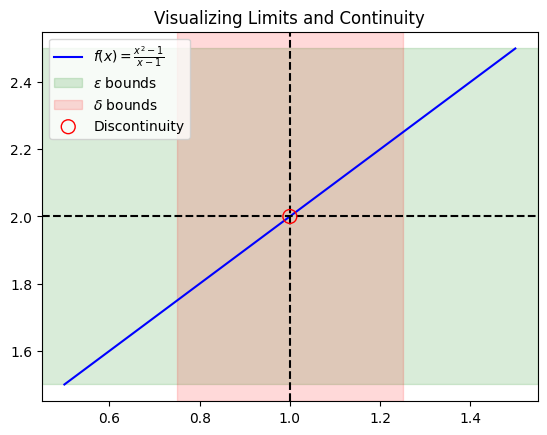

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define function
f_num = lambda x: (x**2 - 1) / (x - 1)

# Target point (c, L)
c = 1
L = 2
epsilon = 0.5
delta = 0.25 # Chosen for visualization

x_vals = np.linspace(0.5, 1.5, 400)
y_vals = f_num(x_vals)

plt.plot(x_vals, y_vals, label=r'$f(x) = \frac{x^2-1}{x-1}$', color='blue')
plt.axvline(c, color='black', linestyle='--')
plt.axhline(L, color='black', linestyle='--')

# Draw epsilon-delta box
plt.axhspan(L - epsilon, L + epsilon, color='green', alpha=0.15, label=r'$\epsilon$ bounds')
plt.axvspan(c - delta, c + delta, color='red', alpha=0.15, label=r'$\delta$ bounds')

plt.scatter([c], [L], color='red', facecolors='none', s=100, zorder=5, label='Discontinuity')
plt.title("Visualizing Limits and Continuity")
plt.legend()
plt.show()

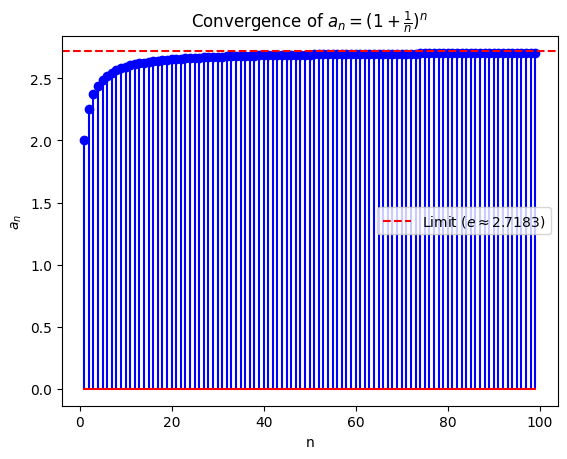

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate sequence values
n = np.arange(1, 100)
a_n = (1 + 1/n)**n

plt.stem(n, a_n, linefmt='b-', markerfmt='bo', basefmt='r-')
plt.axhline(np.e, color='red', linestyle='--', label=rf'Limit ($e \approx {np.e:.4f}$)')
plt.xlabel('n')
plt.ylabel('$a_n$')
plt.title(r'Convergence of $a_n = (1 + \frac{1}{n})^n$')
plt.legend()
plt.show()

In [5]:
def riemann_sum(f, a, b, n, mode='mid'):
    dx = (b - a) / n
    x = np.linspace(a, b, n+1)

    if mode == 'left':
        return np.sum(f(x[:-1]) * dx)
    elif mode == 'right':
        return np.sum(f(x[1:]) * dx)
    elif mode == 'mid':
        x_mid = (x[:-1] + x[1:]) / 2
        return np.sum(f(x_mid) * dx)

# Integrate x^2 from 0 to 1
f = lambda x: x**2
print("Riemann Approx (n=100):", riemann_sum(f, 0, 1, 100))

Riemann Approx (n=100): 0.3333250000000001


<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6070/1819270089.py:10: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(x_vals, np.sin(x_vals), label='Actual $\sin(x)$', lw=3, color='black')


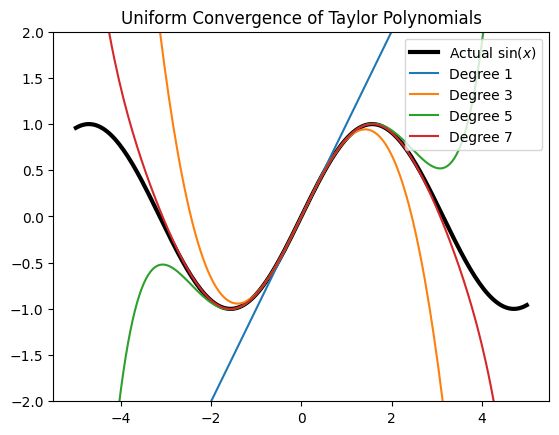

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

x = sp.Symbol('x')
f = sp.sin(x)

# Generate Taylor series approximations of degrees 1, 3, 5
x_vals = np.linspace(-5, 5, 200)
plt.plot(x_vals, np.sin(x_vals), label='Actual $\sin(x)$', lw=3, color='black')

for deg in [1, 3, 5, 7]:
    # Calculate Taylor polynomial symbolically
    taylor_poly = sp.series(f, x, 0, deg+1).removeO()
    # Convert to a fast numerical function
    lam_poly = sp.lambdify(x, taylor_poly, 'numpy')

    plt.plot(x_vals, lam_poly(x_vals), label=f'Degree {deg}')

plt.ylim(-2, 2)
plt.title("Uniform Convergence of Taylor Polynomials")
plt.legend()
plt.show()